In [4]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 840.2 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/9.6 MB 840.2 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.6 MB 763.2 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.6 MB 763.2 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.6 MB 680.3 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.6 MB 680.3 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/9.6 MB 706.6 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9.6 MB 729.4 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/9.6 MB 729.4 kB/s eta 0:00:11
   ------- -----------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


=== Descriptive Statistics ===
Mean: 25808.51
Median: 24192.0
Mode: 1308
Standard Deviation: 13917.63


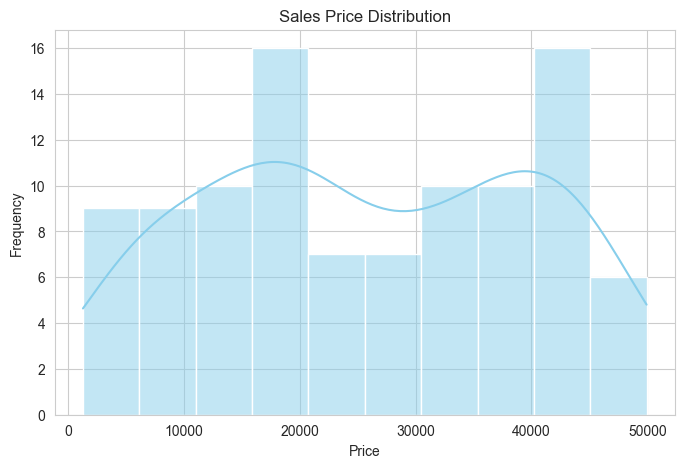

Shapiro-Wilk Test: W=0.948, p=0.0006
Data is not normal.


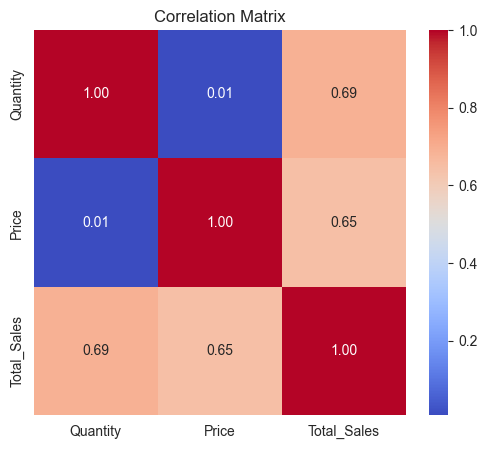

T-test North vs South: t=0.130, p=0.8968
Significant difference between regions? No

ANOVA Table (Total Sales by Region):
                sum_sq    df         F    PR(>F)
Region    6.292020e+10   3.0  2.164363  0.097237
Residual  9.302719e+11  96.0       NaN       NaN

95% Confidence Interval for Total Sales: (103776.34767158539, 143524.6123284146)

=== Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           4.40e-46
Time:                        14:17:31   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                        

In [12]:
# WEEK 7: STATISTICAL ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols


sales = pd.read_csv("sales_data.csv")
churn = pd.read_csv("customer_churn.csv")  # optional, for churn analysis


mean_sales = sales['Price'].mean()
median_sales = sales['Price'].median()
mode_sales = sales['Price'].mode()[0]
std_sales = sales['Price'].std()

print("=== Descriptive Statistics ===")
print(f"Mean: {mean_sales:.2f}")
print(f"Median: {median_sales}")
print(f"Mode: {mode_sales}")
print(f"Standard Deviation: {std_sales:.2f}")


plt.figure(figsize=(8,5))
sns.histplot(sales['Price'], kde=True, bins=10, color='skyblue')
plt.title("Sales Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

shapiro_test = stats.shapiro(sales['Price'])
print(f"Shapiro-Wilk Test: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.4f}")
print("Data is approximately normal." if shapiro_test.pvalue > 0.05 else "Data is not normal.")


numeric_cols = ['Quantity', 'Price', 'Total_Sales']
corr_matrix = sales[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


north_sales = sales[sales['Region'] == 'North']['Total_Sales']
south_sales = sales[sales['Region'] == 'South']['Total_Sales']

t_stat, p_val = stats.ttest_ind(north_sales, south_sales)
print(f"T-test North vs South: t={t_stat:.3f}, p={p_val:.4f}")
print("Significant difference between regions?" , "Yes" if p_val < 0.05 else "No")


anova_model = ols('Total_Sales ~ Region', data=sales).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print("\nANOVA Table (Total Sales by Region):")
print(anova_table)


mean_total = sales['Total_Sales'].mean()
sem = stats.sem(sales['Total_Sales'])
ci = stats.t.interval(0.95, len(sales['Total_Sales'])-1, loc=mean_total, scale=sem)
print(f"\n95% Confidence Interval for Total Sales: {ci}")


X = sales[['Quantity', 'Price']]
y = sales['Total_Sales']
X = sm.add_constant(X)  # Add intercept
model = sm.OLS(y, X).fit()
print("\n=== Regression Summary ===")
print(model.summary())
print(f"R-squared: {model.rsquared:.2f}")



print("\n Key Insights:")
print(f"- Average Sales Price: ${mean_sales:.2f}")
print(f"- Sales Distribution approximately normal? {'Yes' if shapiro_test.pvalue > 0.05 else 'No'}")
print(f"- Correlation (Quantity vs Total_Sales): {corr_matrix.loc['Quantity','Total_Sales']:.2f}")
print(f"- North vs South Sales Difference Significant? {'Yes' if p_val < 0.05 else 'No'}")
print("- Regression model can predict total sales based on Quantity and Price.")
print("- ANOVA shows if sales differ across all regions (check p-value in table above).")
